In [1]:
import numpy as np
import matplotlib.pylab as plt
import pickle

In [2]:
filename = 'Block5_CGT.pkl'

with open(filename,'rb') as file:
    CGT01 = pickle.load(file)
CGT_Bl5T01 = CGT01

In [3]:
np.set_printoptions(precision=1000)

## Methods

In [4]:
#Bond length
b = 2**(1/6)

#Ree parameters
Nlpf = 10009
M = 100; N = 100
Ndata = int(M*N)
Ncols = 9

#Get End-to-end distance
def Ree(D):
    
    # ITEM: ATOMS id mol type xu yu zu vx vy vz
    Nf = D.shape[0]
    
    #Extract all atoms that are type 3
    Type3 = D[D[:,:,2] == 3]
    Type3 = Type3.reshape(Nf, 100, 9)

    #Extract all atoms that are type 4
    Type4 = D[D[:,:,2] == 4]
    Type4 = Type4.reshape(Nf, 100, 9)

    #Extract Position vector
    Type3 = Type3[1:,:,3:6] #Exclude first frame
    Type4 = Type4[1:,:,3:6]

    #Extract End-to-end vector
    dX = Type3-Type4
    Rhp = np.linalg.norm(dX, axis = 2)
    
    return Rhp

#Get segmental end-to-end distance
def segRee(D, Blck, Atom_Type):
    Nf = D.shape[0]
    Mseg = N//Blck*M
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,Blck,9) #exclude first frame

    Xseg = D[:,:,:,3:6]

    if(Atom_Type == 'Hydrophilic'):
        # Get just the odd segments (hydrophilic segments)
        Xhp =  Xseg[:,1::2,:,:]
    elif(Atom_Type == 'Hydrophobic'):
        # Get just the even segments (hydrophobic segments)
        Xhp =  Xseg[:,0::2,:,:]
    
    # End-to-End vectors of the segments
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)
    return Rhp

# Radius of Gyration
# Xcom = Xhp.mean(axis=2)
# dX = Xhp-Xcom[:,:,np.newaxis,:]
# Rg = np.mean((dX**2).sum(axis=3),axis=2)**0.5

# h,edges = np.histogram(Rg.flatten(),bins=100)
# xh = (edges[:-1]+edges[1:])/2
# plt.plot(xh,h,lw=3)

# #Examine trajectory of hydrophobic segments
# #Should be used to examine individual parsed data
# def SegTraj(Rhp):
#     # Plot Some Segmental Trajectories
#     fg,ax = plt.subplots(1,1,figsize=(8,6))

#     Rhp.shape
#     for m in range(1000):
#         ax.plot(Rhp[:,m],'b-',lw=1.5,alpha=0.05)
        
#     for m in np.arange(0,1000,50):
#         ax.plot(Rhp[:,m],'-',lw=2.5)

## Block 5, T = 0.1

In [5]:
#Define bin size and domain of order parameter
bin = 80
domain = [1, 4.1]
rang = np.linspace(domain[0], domain[1], bin + 1)
xh = (rang[:-1]+rang[1:])/2

Text(0.5, 1.0, 'Histogram for Hydrophilic Sections')

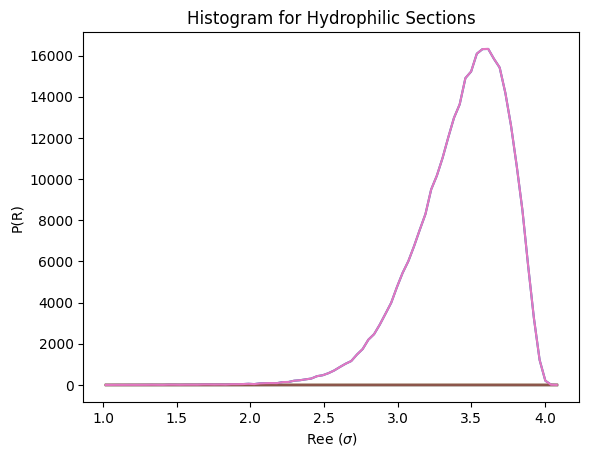

In [6]:
Hphilic = xh*0
for i in range(5,21):
    f = CGT_Bl5T01.f[i]-0.5
    D = segRee(CGT_Bl5T01.ParsedRee[i], 5, 'Hydrophilic').flatten()
    kT = 0.1
    w = np.exp(-f*D/kT)
    prob = np.histogram(D,bins=rang, weights = w)[0]
    Hphilic += prob
    plt.plot(xh, prob, label = 'f = ' + str(CGT_Bl5T01.f[i]))
plt.plot(xh, Hphilic)
plt.xlabel("Ree ($\sigma$)")
plt.ylabel("P(R)")
plt.title('Histogram for Hydrophilic Sections')

Text(0.5, 1.0, 'Histogram for Hydrophobic Sections')

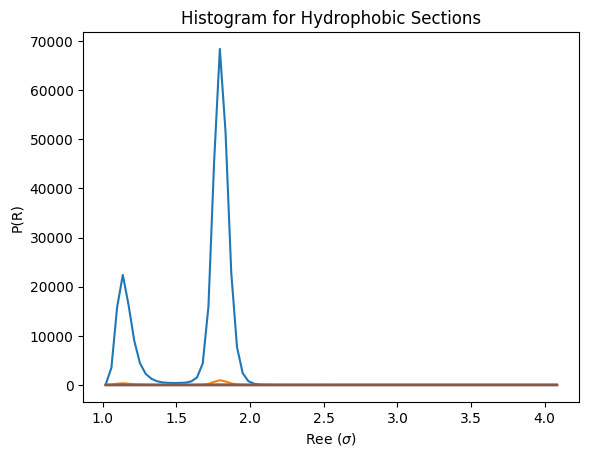

In [7]:
Hphobic = xh*0
for i in range(5,21):
    f = CGT_Bl5T01.f[i]-CGT_Bl5T01.f[5]
    D = segRee(CGT_Bl5T01.ParsedRee[i], 5, 'Hydrophobic').flatten()
    kT = 0.1
    w = np.exp(-f*D/kT)
    prob = np.histogram(D,bins=rang,weights = w)[0]
    Hphobic += prob
    plt.plot(xh, prob)
# plt.plot(xh, Hphobic, label='Hphobic')
plt.xlabel("Ree ($\sigma$)")
plt.ylabel("P(R)")
plt.title('Histogram for Hydrophobic Sections')

/tmp/ipykernel_178588/3193562819.py:3: RuntimeWarning: divide by zero encountered in log
  Hphilic = -0.1*np.log(Hphilic/Hphilic.sum())


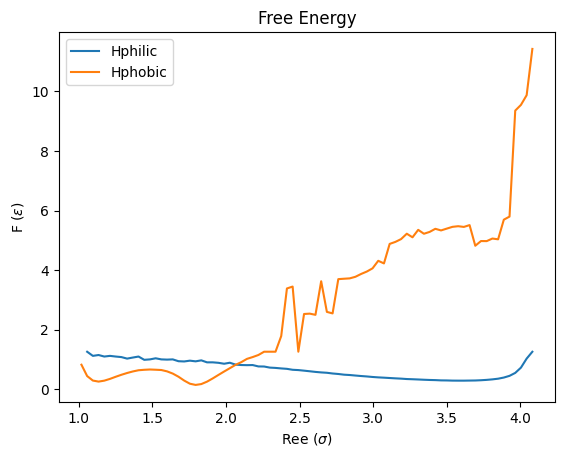

In [8]:
#Free Energy of Hydrophobic and Hydrophilic Sections
Hphobic = -0.1*np.log(Hphobic/Hphobic.sum())
Hphilic = -0.1*np.log(Hphilic/Hphilic.sum())
plt.plot(xh, Hphilic, label = 'Hphilic')
plt.plot(xh, Hphobic, label = 'Hphobic')
plt.legend()
plt.title('Free Energy')
plt.xlabel("Ree ($\sigma$)")
plt.ylabel("F ($\epsilon$)")
plt.savefig('../Data/Block5/Figures/Block5FE')

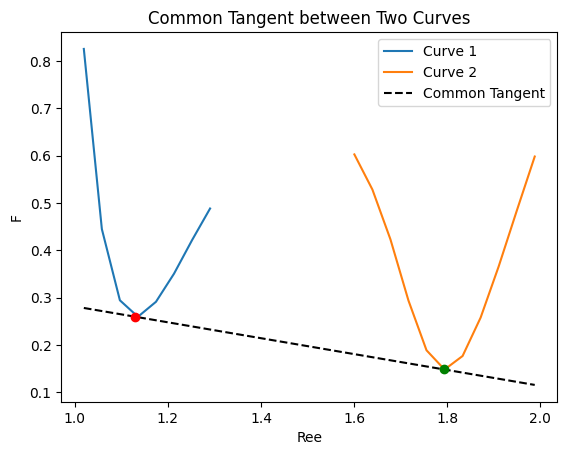

In [9]:
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize

mask1 = (1 < xh) & (xh < 1.3)
mask2 = (1.6 < xh) & (xh < 2)

# Input
x1 = xh[mask1]
y1 = Hphobic[mask1]

x2 = xh[mask2]
y2 = Hphobic[mask2]

# Fit splines to both curves
curve1 = CubicSpline(x1, y1)
curve2 = CubicSpline(x2, y2)

# Objective function: squared difference of tangents and point-to-line difference
def objective(p):
    t1, t2 = p  # candidate points on curve1 and curve2
    y1_val, y2_val = curve1(t1), curve2(t2)
    dy1, dy2 = curve1.derivative()(t1), curve2.derivative()(t2)

    # Minimize: difference in slopes and vertical distance between points along the common tangent
    slope_diff = dy1 - dy2
    y_line_at_t2 = y1_val + dy1 * (t2 - t1)
    y_diff = y_line_at_t2 - y2_val

    return slope_diff**2 + y_diff**2

# Initial guess (can be improved)
initial_guess = [x1[len(x1)//2], x2[len(x2)//2]]

# Minimize the objective function
result = minimize(objective, initial_guess, bounds=[(x1[0], x1[-1]), (x2[0], x2[-1])])
t1_opt, t2_opt = result.x

# Compute points and common tangent
pt1 = np.array([t1_opt, curve1(t1_opt)])
pt2 = np.array([t2_opt, curve2(t2_opt)])
slope = curve1.derivative()(t1_opt)

# Define tangent line function
def tangent_line(x):
    return pt1[1] + slope * (x - pt1[0])

# Plotting
x_vals = np.linspace(min(x1[0], x2[0]), max(x1[-1], x2[-1]), 500)
plt.plot(x1, y1, label='Curve 1')
plt.plot(x2, y2, label='Curve 2')
plt.plot(x_vals, tangent_line(x_vals), '--k', label='Common Tangent')
plt.plot(*pt1, 'ro')
plt.plot(*pt2, 'go')
plt.legend()
plt.xlabel('Ree')
plt.ylabel('F')
plt.title('Common Tangent between Two Curves')
plt.show()

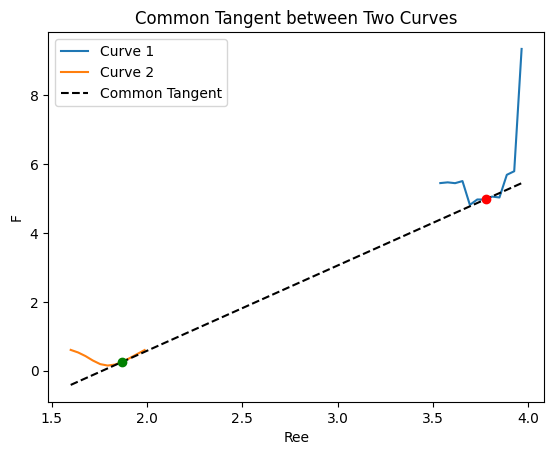

In [10]:
mask3 = (xh > 3.5) & (xh < 4)

# Input
x1 = xh[mask3]
y1 = Hphobic[mask3]

x2 = xh[mask2]
y2 = Hphobic[mask2]

# Fit splines to both curves
curve1 = CubicSpline(x1, y1)
curve2 = CubicSpline(x2, y2)

# Initial guess (can be improved)
initial_guess = [x1[len(x1)//2], x2[len(x2)//2]]

# Minimize the objective function
result = minimize(objective, initial_guess, bounds=[(x1[0], x1[-1]), (x2[0], x2[-1])])
t1_opt, t2_opt = result.x

# Compute points and common tangent
pt1 = np.array([t1_opt, curve1(t1_opt)])
pt2 = np.array([t2_opt, curve2(t2_opt)])
slope2 = curve1.derivative()(t1_opt)

# Define tangent line function
def tangent_line(x):
    return pt1[1] + slope2 * (x - pt1[0])

# Plotting
x_vals = np.linspace(min(x1[0], x2[0]), max(x1[-1], x2[-1]), 500)
plt.plot(x1, y1, label='Curve 1')
plt.plot(x2, y2, label='Curve 2')
plt.plot(x_vals, tangent_line(x_vals), '--k', label='Common Tangent')
plt.plot(*pt1, 'ro')
plt.plot(*pt2, 'go')
plt.legend()
plt.xlabel('Ree')
plt.ylabel('F')
plt.title('Common Tangent between Two Curves')
plt.show()

In [11]:
def FJC(x):
    return 1 / np.tanh(x) - 1 / x

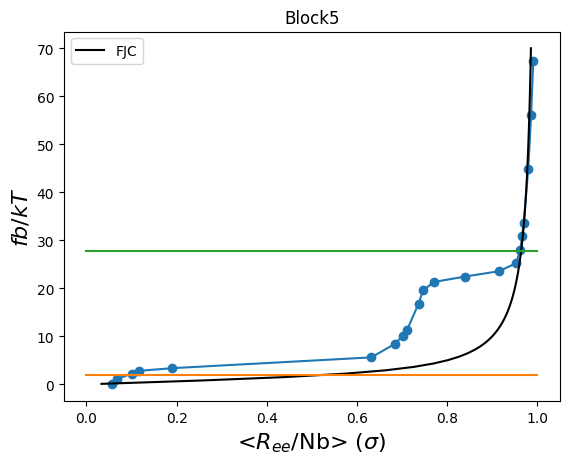

In [12]:
#Below Critical temperature
force = np.array(CGT_Bl5T01.f)
plt.plot(CGT_Bl5T01.aveRee / 99,force*b / 0.1, 'o-')

fbkt = np.linspace(0.1, 70,100)

#Define Proportion
R1 = pt1[0]
R2 = pt2[0]
# X=(R2-lsR)/(R2-R1)
# print(X)
# R = (R1*X+R2*(1-X)+5*FJC(lsF*b/0.1))*10/99

# plt.plot(R, lsF*b/0.1)

plt.plot(FJC(fbkt),fbkt, color = 'k', label = 'FJC')
plt.plot([0,1], [-slope*b/0.1]*2)
plt.plot([0,1], [slope2*b/0.1]*2)
plt.ylabel('$fb/kT$', fontsize=16)
plt.xlabel('<$R_{ee}$/Nb> ($\sigma$)', fontsize=16)
plt.title('Block5')
plt.legend()

## Whole Chain

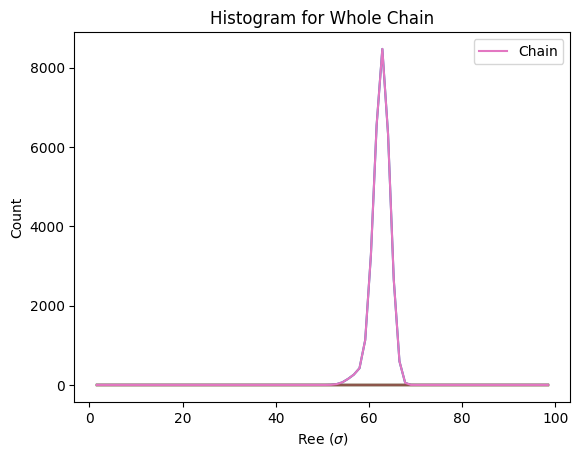

In [13]:
#Whole Chain
#Redefine Range for the whole chain
rang_chain = np.linspace(1, 99, bin+1)
xh_chain = (rang_chain[:-1]+rang_chain[1:])/2
    
Hchain = xh*0
for i in range(5,21):
    f = CGT_Bl5T01.f[i]-0.5
    D = Ree(CGT_Bl5T01.ParsedRee[i]).flatten()
    kT = 0.1
    w = np.exp(-f*D/kT)
    prob = np.histogram(D,bins=rang_chain, weights = w)[0]
    Hchain += prob
    plt.plot(xh_chain, prob)

plt.plot(xh_chain, Hchain, label='Chain')
plt.xlabel("Ree ($\sigma$)")
plt.ylabel("Count")
plt.title('Histogram for Whole Chain')
plt.legend()

/tmp/ipykernel_178588/2107040446.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot(xh_chain, -0.1*np.log(Hchain))


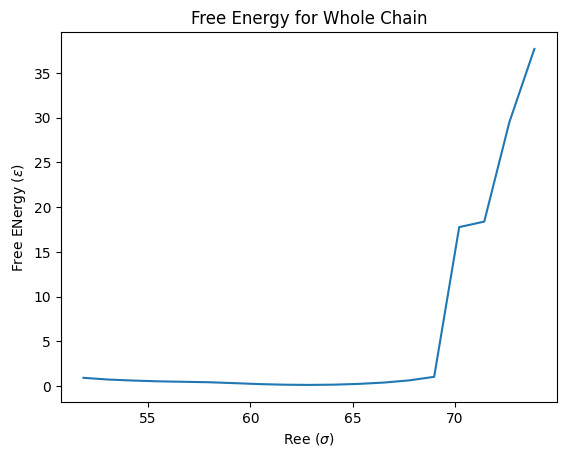

In [14]:
Hchain = Hchain/Hchain.sum()
plt.plot(xh_chain, -0.1*np.log(Hchain))
plt.xlabel("Ree ($\sigma$)")
plt.ylabel("Free ENergy ($\epsilon$)")
plt.title('Free Energy for Whole Chain')
plt.savefig('../Data/Block5/Figures/WholeChainFE')

In [15]:
# from pymbar import testsystems
# from pymbar import MBAR
# x_n, u_kn, N_k, s_n = testsystems.HarmonicOscillatorsTestCase().sample()
# mbar = MBAR(u_kn, N_k)
# results = mbar.compute_free_energy_differences()
# diff = results['Delta_f']